# Лабораторная работа №1
### «Анализ и прогнозирование временных рядов на примере розничных продаж»

Цель: Провести анализ временного ряда розничных продаж, выполнить декомпозицию, построить модели ARIMA и SARIMAX.

Данные: retail_sales_mock_data.csv — месячные продажи за 2020-2023 гг.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.fft import fft, fftfreq
import pywt

from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
plt.style.use('seaborn-v0_8-whitegrid')

### Загрузка данных

In [3]:
df = pd.read_csv('retail_sales_mock_data.csv', parse_dates=['Date'])
df.set_index('Date', inplace=True)
df.index.freq = 'MS'

print(f"Размер: {df.shape}")
print(f"Период: {df.index.min()} — {df.index.max()}")
df.info()
df.head(10)

Размер: (48, 3)
Период: 2020-01-01 00:00:00 — 2023-12-01 00:00:00
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 48 entries, 2020-01-01 to 2023-12-01
Freq: MS
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   SalesAmount   48 non-null     int64
 1   Promotion     48 non-null     int64
 2   HolidayMonth  48 non-null     int64
dtypes: int64(3)
memory usage: 1.5 KB


,SalesAmount,Promotion,HolidayMonth
Date,,,
2020-01-01,12248,0,0
2020-02-01,13011,0,0
2020-03-01,12722,0,0
2020-04-01,14030,1,0
2020-05-01,7783,0,0
2020-06-01,9131,1,0
2020-07-01,9089,0,0
2020-08-01,10300,0,0
2020-09-01,10464,0,0


## 2.1. Разведочный анализ данных (EDA)

In [4]:
# Описательная статистика временного ряда

sales = df['SalesAmount']

stats_df = pd.DataFrame({
    'Показатель': [
        'Количество наблюдений',
        'Среднее значение',
        'Стандартное отклонение',
        'Минимум',
        '1-й квартиль',
        'Медиана',
        '3-й квартиль',
        'Максимум',
        'Размах',
        'Коэффициент вариации (%)',
        'Асимметрия',
        'Эксцесс'
    ],
    'Значение': [
        len(sales),
        round(sales.mean(), 2),
        round(sales.std(), 2),
        round(sales.min(), 2),
        round(sales.quantile(0.25), 2),
        round(sales.median(), 2),
        round(sales.quantile(0.75), 2),
        round(sales.max(), 2),
        round(sales.max() - sales.min(), 2),
        round((sales.std() / sales.mean()) * 100, 2),
        round(sales.skew(), 3),
        round(sales.kurtosis(), 3)
    ]
})

print(stats_df.to_string(index=False))

print(f"\nКоличество пропусков: {sales.isna().sum()}")

Q1 = sales.quantile(0.25)
Q3 = sales.quantile(0.75)

IQR = Q3 - Q1

outliers = sales[
    (sales < (Q1 - 1.5 * IQR)) |
    (sales > (Q3 + 1.5 * IQR))
]

print(f"Количество выбросов по IQR: {len(outliers)}")

              Показатель  Значение
   Количество наблюдений    48.000
        Среднее значение 11768.540
  Стандартное отклонение  2257.540
                 Минимум  7783.000
            1-й квартиль 10219.750
                 Медиана 11851.000
            3-й квартиль 13014.000
                Максимум 17996.000
                  Размах 10213.000
Коэффициент вариации (%)    19.180
              Асимметрия     0.391
                 Эксцесс     0.165

Количество пропусков: 0
Количество выбросов по IQR: 1


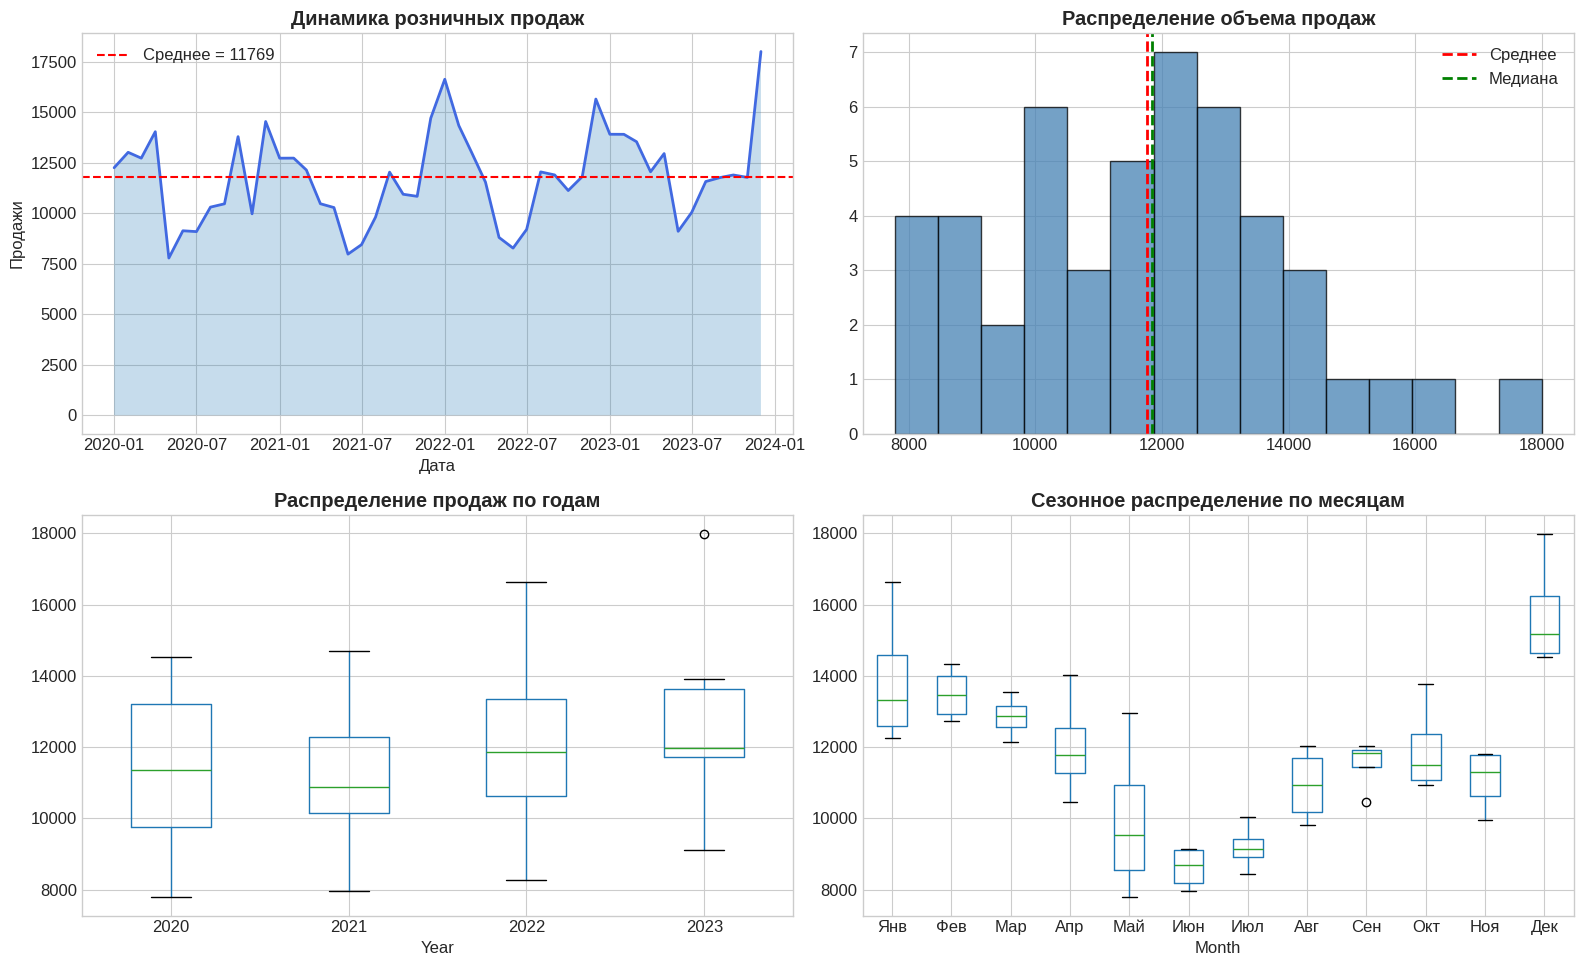

In [5]:
# Визуализация временного ряда

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Исходный временной ряд
axes[0, 0].plot(
    sales.index,
    sales.values,
    color='royalblue',
    linewidth=2
)

axes[0, 0].fill_between(
    sales.index,
    sales.values,
    alpha=0.25
)

axes[0, 0].axhline(
    y=sales.mean(),
    color='red',
    linestyle='--',
    label=f'Среднее = {sales.mean():.0f}'
)

axes[0, 0].set_title(
    'Динамика розничных продаж',
    fontweight='bold'
)

axes[0, 0].set_xlabel('Дата')
axes[0, 0].set_ylabel('Продажи')
axes[0, 0].legend()

# Гистограмма распределения
axes[0, 1].hist(
    sales.values,
    bins=15,
    color='steelblue',
    edgecolor='black',
    alpha=0.75
)

axes[0, 1].axvline(
    sales.mean(),
    color='red',
    linestyle='--',
    linewidth=2,
    label='Среднее'
)

axes[0, 1].axvline(
    sales.median(),
    color='green',
    linestyle='--',
    linewidth=2,
    label='Медиана'
)

axes[0, 1].set_title(
    'Распределение объема продаж',
    fontweight='bold'
)

axes[0, 1].legend()

# Boxplot по годам
df_yearly = df.copy()
df_yearly['Year'] = df_yearly.index.year

df_yearly.boxplot(
    column='SalesAmount',
    by='Year',
    ax=axes[1, 0]
)

axes[1, 0].set_title(
    'Распределение продаж по годам',
    fontweight='bold'
)

# Boxplot по месяцам
df_monthly = df.copy()
df_monthly['Month'] = df_monthly.index.month

month_names = [
    'Янв', 'Фев', 'Мар', 'Апр',
    'Май', 'Июн', 'Июл', 'Авг',
    'Сен', 'Окт', 'Ноя', 'Дек'
]

df_monthly.boxplot(
    column='SalesAmount',
    by='Month',
    ax=axes[1, 1]
)

axes[1, 1].set_xticklabels(month_names)

axes[1, 1].set_title(
    'Сезонное распределение по месяцам',
    fontweight='bold'
)

plt.suptitle('')
plt.tight_layout()
plt.show()

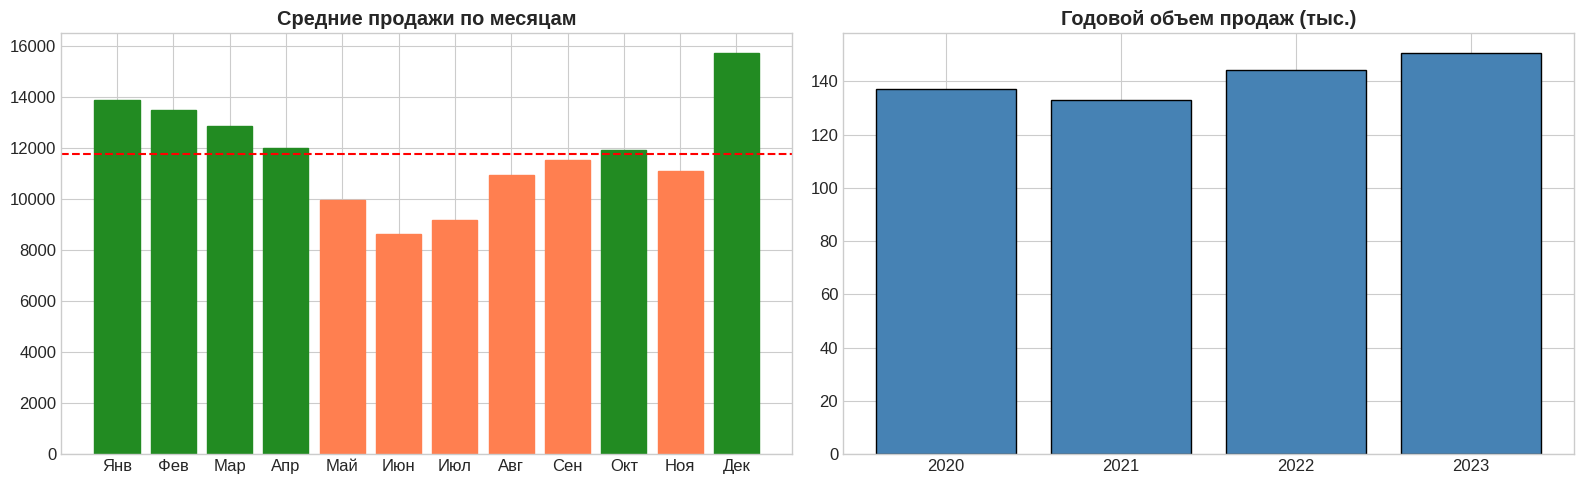

In [6]:
# Дополнительный анализ сезонности и годовой динамики

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Средние продажи по месяцам
monthly_avg = df.groupby(df.index.month)['SalesAmount'].mean()

bars = axes[0].bar(
    range(1, 13),
    monthly_avg.values,
    edgecolor='black'
)

for bar, value in zip(bars, monthly_avg.values):
    bar.set_color(
        'forestgreen' if value > sales.mean() else 'coral'
    )

axes[0].axhline(
    y=sales.mean(),
    color='red',
    linestyle='--'
)

axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(month_names)

axes[0].set_title(
    'Средние продажи по месяцам',
    fontweight='bold'
)

# Годовой объем продаж
yearly_stats = df.groupby(df.index.year)['SalesAmount'].sum()

axes[1].bar(
    range(len(yearly_stats)),
    yearly_stats.values / 1000,
    color='steelblue',
    edgecolor='black'
)

axes[1].set_xticks(range(len(yearly_stats)))
axes[1].set_xticklabels(yearly_stats.index)

axes[1].set_title(
    'Годовой объем продаж (тыс.)',
    fontweight='bold'
)

plt.tight_layout()
plt.show()

In [7]:
# Анализ стационарности временного ряда

def adf_test(series, title=''):

    result = adfuller(
        series.dropna(),
        autolag='AIC'
    )

    print(f"\nADF тест {title}")
    print(f"Статистика теста: {result[0]:.4f}")
    print(f"p-value: {result[1]:.6f}")

    for key, value in result[4].items():
        print(f"{key}: {value:.4f}")

    print(
        f"Вывод: "
        f"{'Ряд стационарен' if result[1] < 0.05 else 'Ряд нестационарен'}"
    )

    return result[1] < 0.05


def kpss_test(series, title=''):

    result = kpss(
        series.dropna(),
        regression='c',
        nlags='auto'
    )

    print(f"\nKPSS тест {title}")
    print(f"Статистика теста: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")

    print(
        f"Вывод: "
        f"{'Ряд стационарен' if result[1] >= 0.05 else 'Ряд нестационарен'}"
    )

    return result[1] >= 0.05


adf_test(sales, '(исходный ряд)')
kpss_test(sales, '(исходный ряд)')


ADF тест (исходный ряд)
Статистика теста: -4.5142
p-value: 0.000185
1%: -3.5966
5%: -2.9333
10%: -2.6050
Вывод: Ряд стационарен

KPSS тест (исходный ряд)
Статистика теста: 0.1388
p-value: 0.1000
Вывод: Ряд стационарен


/tmp/ipykernel_14145/2550321726.py:27: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(


np.True_

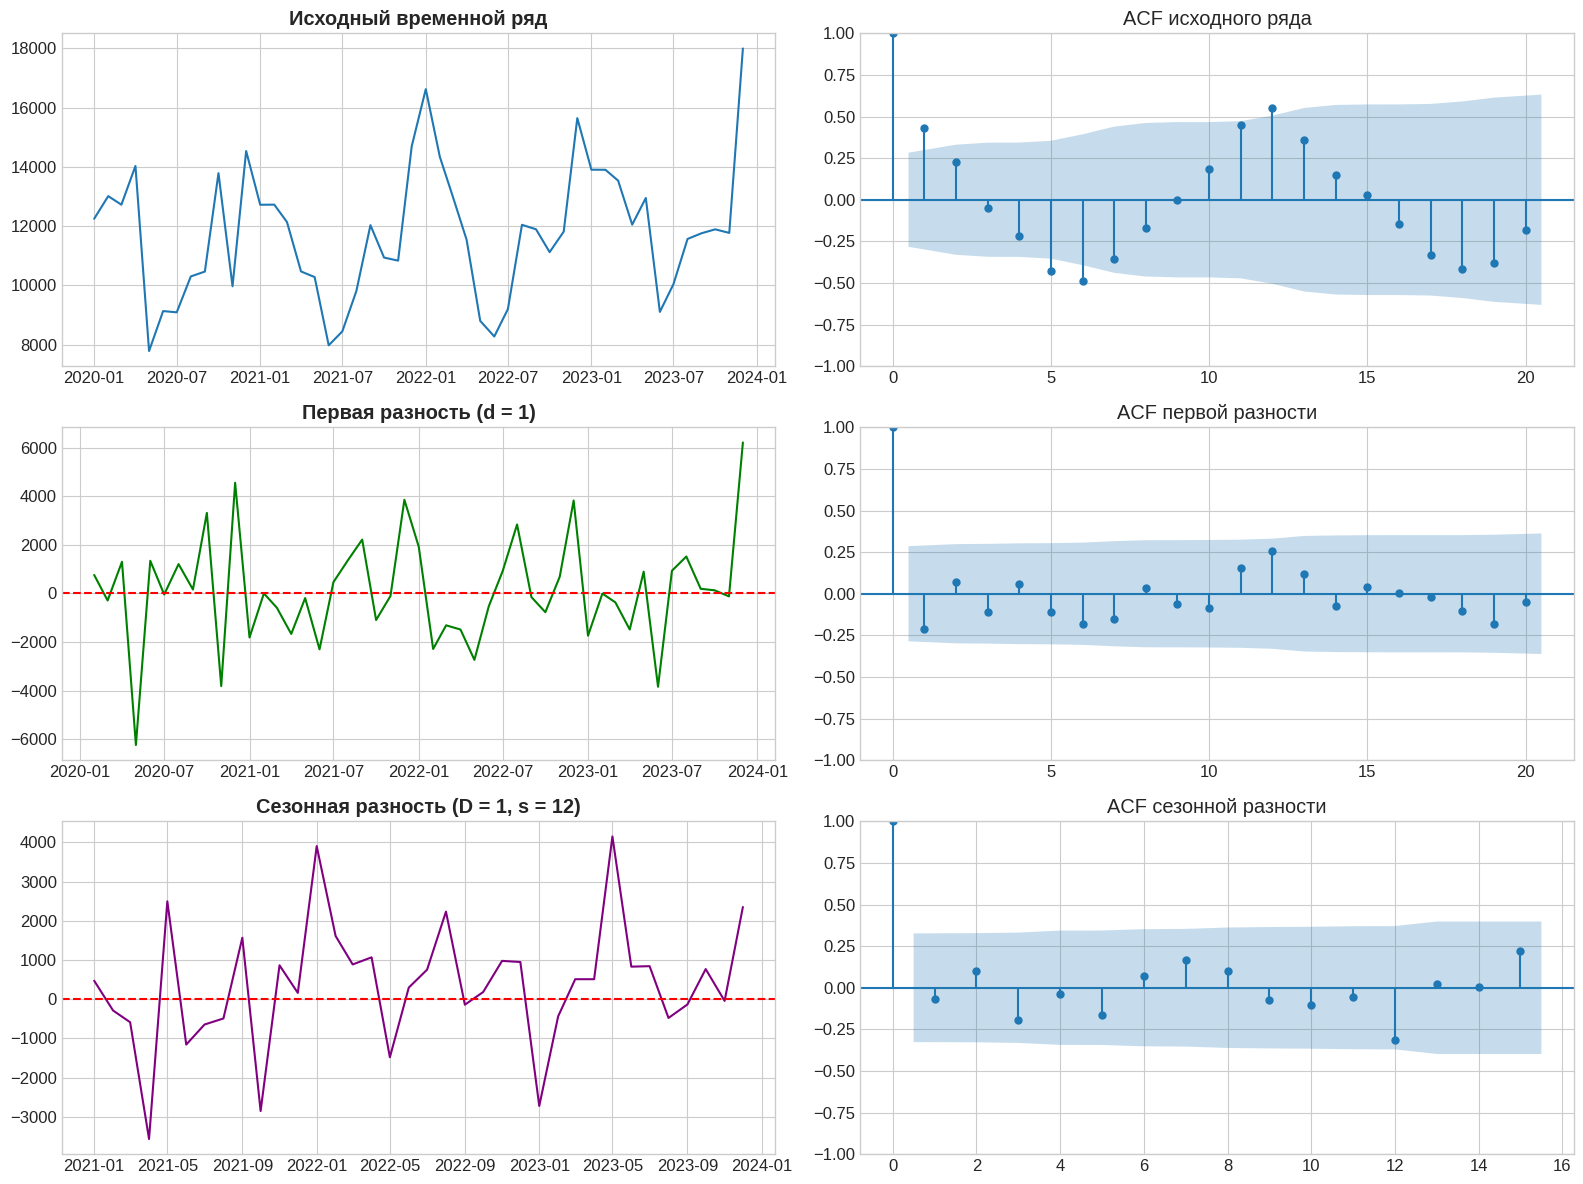


ADF тест (первая разность)
Статистика теста: -5.6296
p-value: 0.000001
1%: -3.6267
5%: -2.9460
10%: -2.6117
Вывод: Ряд стационарен

ADF тест (сезонная разность)
Статистика теста: -3.6261
p-value: 0.005281
1%: -3.6535
5%: -2.9572
10%: -2.6176
Вывод: Ряд стационарен


np.True_

In [8]:
# Дифференцирование временного ряда

sales_diff1 = sales.diff().dropna()

sales_diff_seasonal = sales.diff(12).dropna()

fig, axes = plt.subplots(3, 2, figsize=(16, 12))

# Исходный ряд
axes[0, 0].plot(
    sales.index,
    sales.values,
    linewidth=1.5
)

axes[0, 0].set_title(
    'Исходный временной ряд',
    fontweight='bold'
)

plot_acf(
    sales,
    ax=axes[0, 1],
    lags=20,
    title='ACF исходного ряда'
)

# Первая разность
axes[1, 0].plot(
    sales_diff1.index,
    sales_diff1.values,
    color='green',
    linewidth=1.5
)

axes[1, 0].axhline(
    y=0,
    color='red',
    linestyle='--'
)

axes[1, 0].set_title(
    'Первая разность (d = 1)',
    fontweight='bold'
)

plot_acf(
    sales_diff1,
    ax=axes[1, 1],
    lags=20,
    title='ACF первой разности'
)

# Сезонная разность
axes[2, 0].plot(
    sales_diff_seasonal.index,
    sales_diff_seasonal.values,
    color='purple',
    linewidth=1.5
)

axes[2, 0].axhline(
    y=0,
    color='red',
    linestyle='--'
)

axes[2, 0].set_title(
    'Сезонная разность (D = 1, s = 12)',
    fontweight='bold'
)

plot_acf(
    sales_diff_seasonal,
    ax=axes[2, 1],
    lags=15,
    title='ACF сезонной разности'
)

plt.tight_layout()
plt.show()

adf_test(sales_diff1, '(первая разность)')
adf_test(sales_diff_seasonal, '(сезонная разность)')

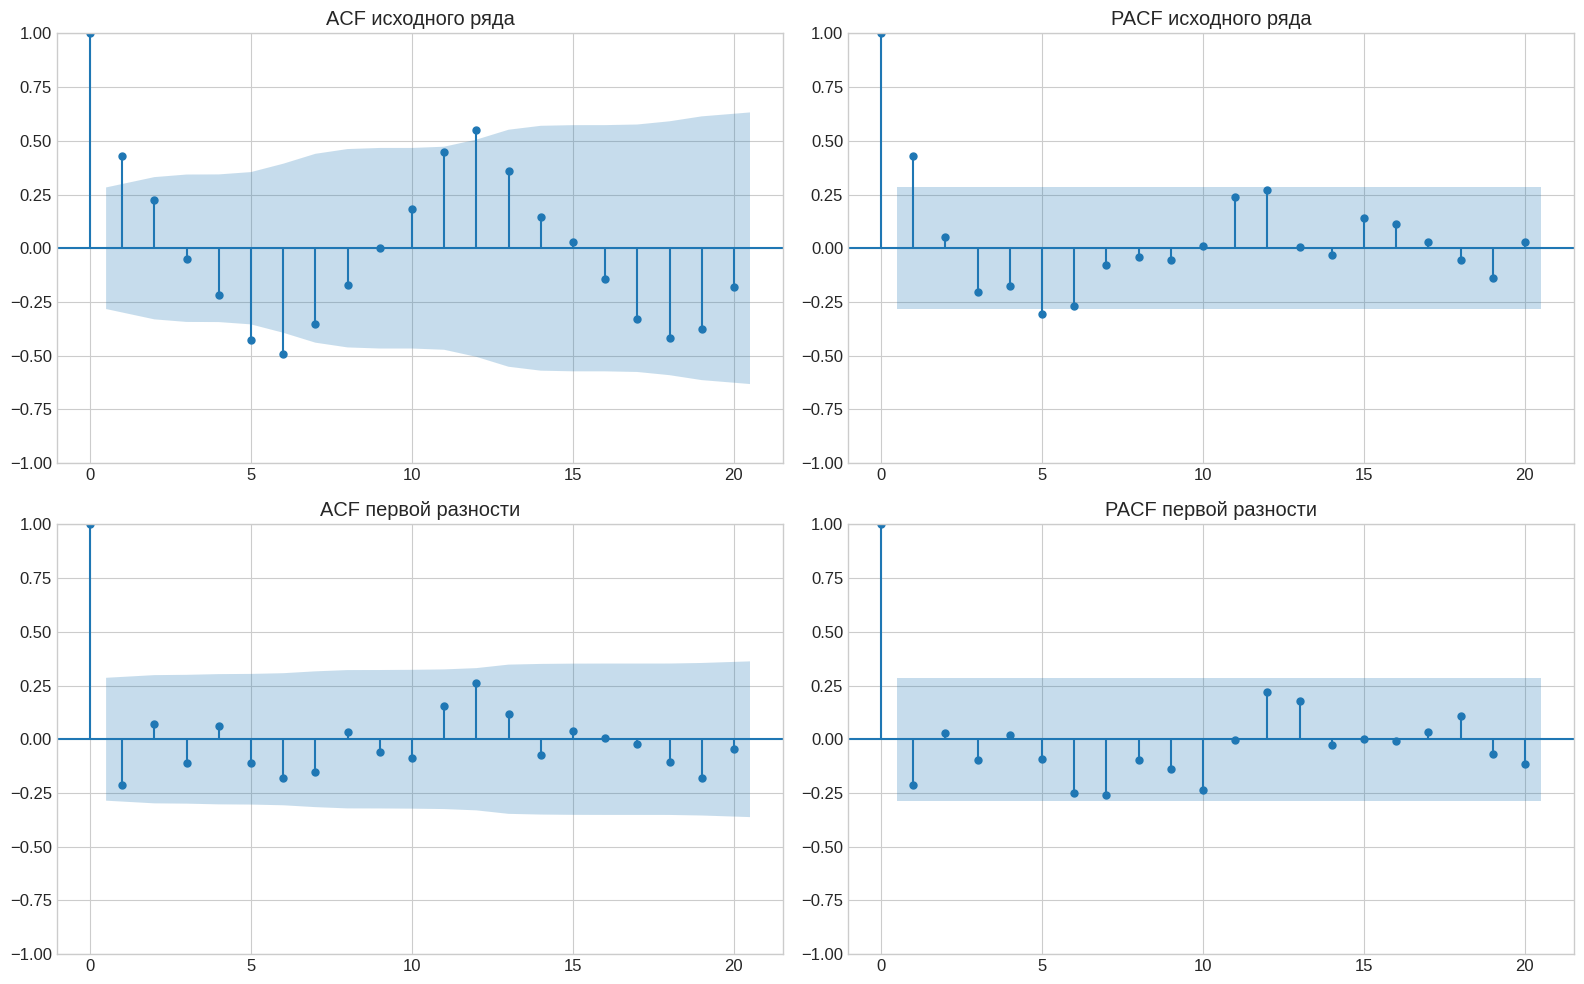


Интерпретация графиков ACF/PACF:
- Медленное затухание ACF указывает на нестационарность ряда;
- Значимые пики на лагах 12 свидетельствуют о сезонности;
- После дифференцирования ряд становится ближе к стационарному;
- Предварительные параметры:
  d = 1, D = 1, s = 12,
  p = 1-2, q = 1-2,
  P = 1, Q = 1.



In [9]:
# ACF и PACF анализ

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

max_lags_original = min(20, len(sales) // 2 - 1)
max_lags_diff = min(20, len(sales_diff1) // 2 - 1)

# Исходный ряд
plot_acf(
    sales,
    ax=axes[0, 0],
    lags=max_lags_original,
    title='ACF исходного ряда'
)

plot_pacf(
    sales,
    ax=axes[0, 1],
    lags=max_lags_original,
    title='PACF исходного ряда',
    method='ywm'
)

# Первая разность
plot_acf(
    sales_diff1,
    ax=axes[1, 0],
    lags=max_lags_diff,
    title='ACF первой разности'
)

plot_pacf(
    sales_diff1,
    ax=axes[1, 1],
    lags=max_lags_diff,
    title='PACF первой разности',
    method='ywm'
)

plt.tight_layout()
plt.show()

print("""
Интерпретация графиков ACF/PACF:
- Медленное затухание ACF указывает на нестационарность ряда;
- Значимые пики на лагах 12 свидетельствуют о сезонности;
- После дифференцирования ряд становится ближе к стационарному;
- Предварительные параметры:
  d = 1, D = 1, s = 12,
  p = 1-2, q = 1-2,
  P = 1, Q = 1.
""")

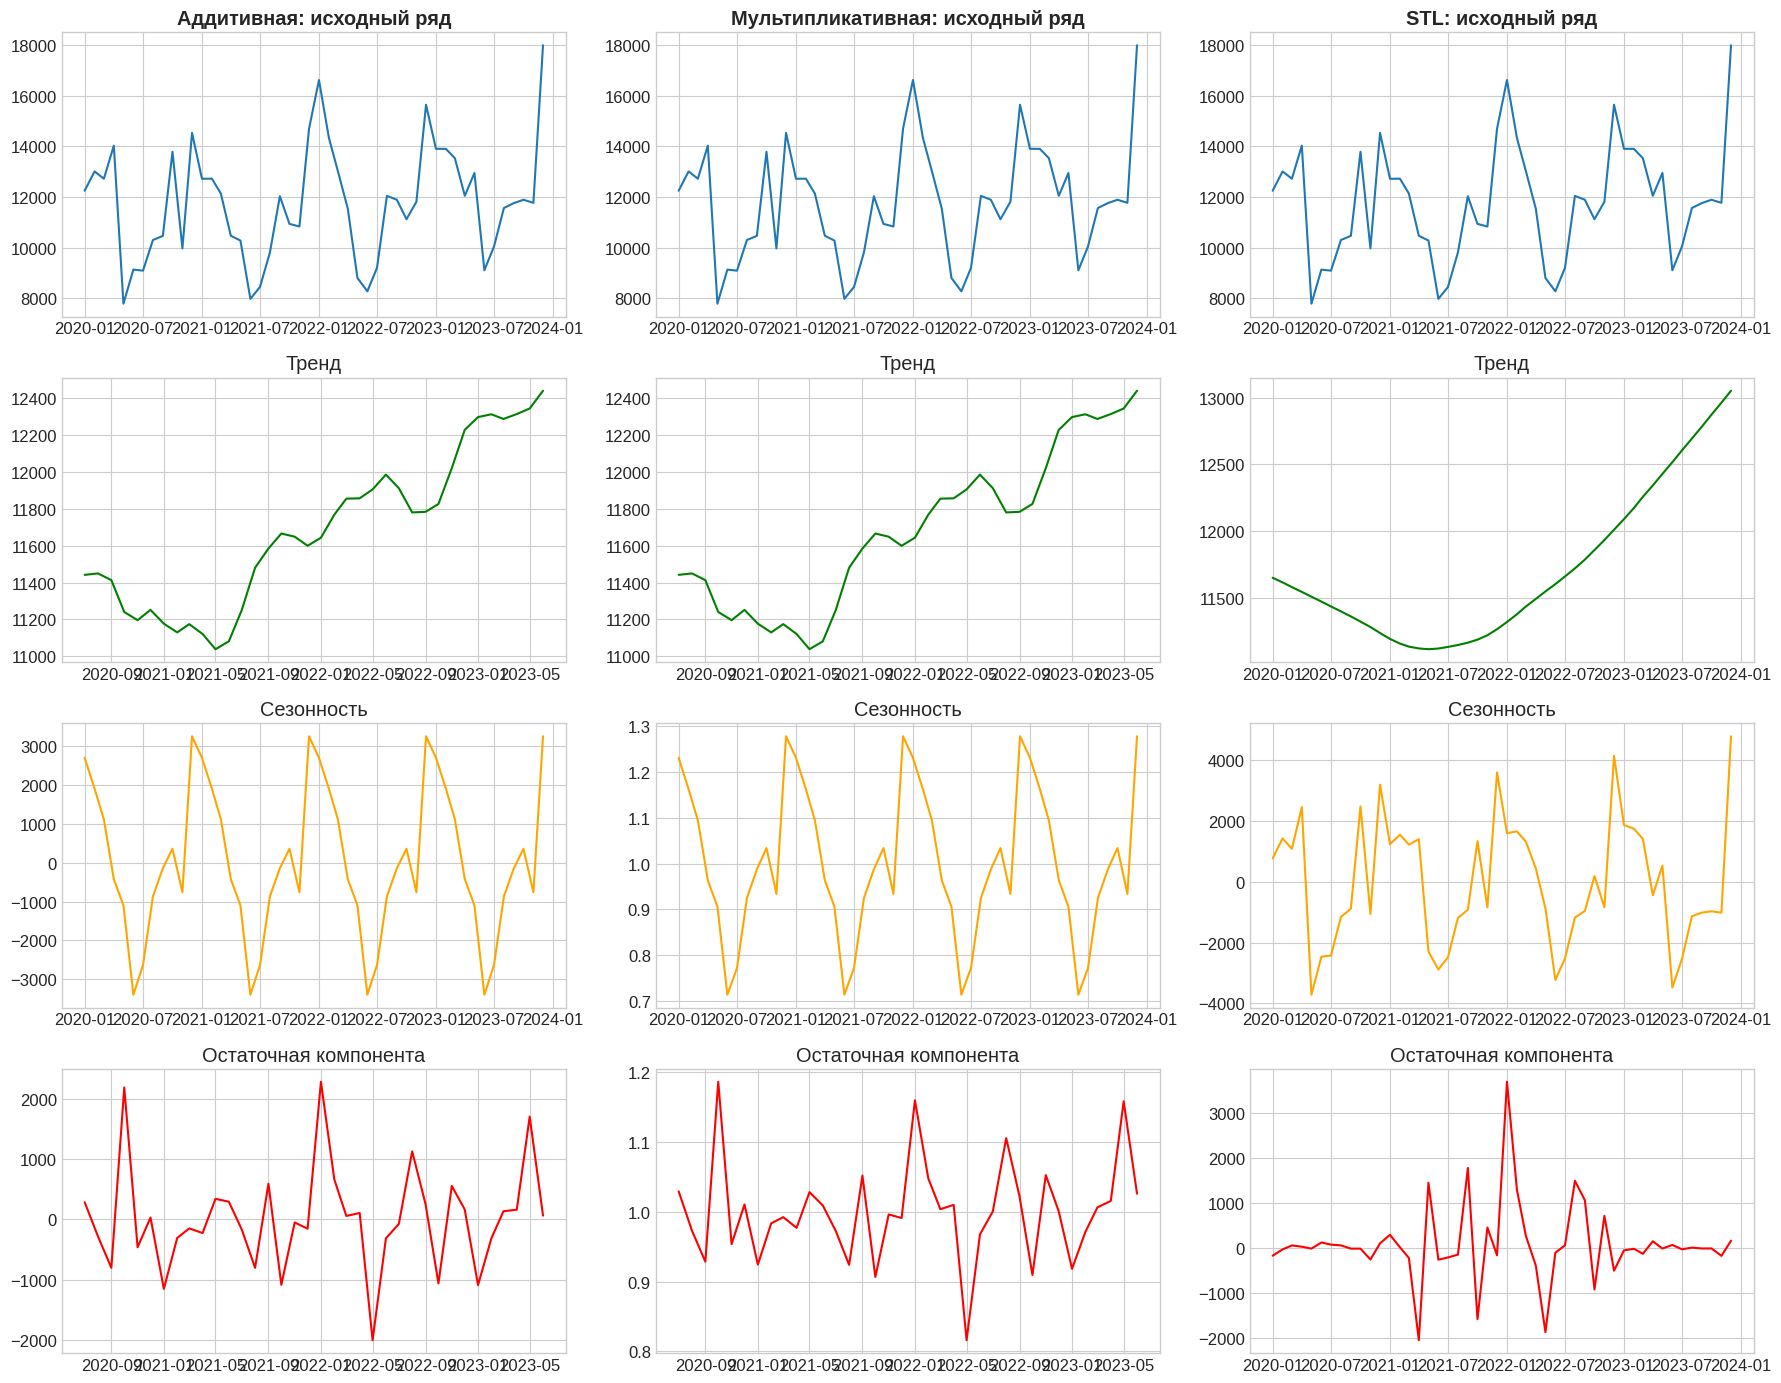

Дисперсия остатков моделей:
Аддитивная модель: 738,286
Мультипликативная модель: 0.0052
STL-декомпозиция: 762,876


In [10]:
# Декомпозиция временного ряда
# Классическая декомпозиция и STL

decomp_add = seasonal_decompose(
    sales,
    model='additive',
    period=12
)

decomp_mult = seasonal_decompose(
    sales,
    model='multiplicative',
    period=12
)

stl = STL(
    sales,
    period=12,
    robust=True
)

decomp_stl = stl.fit()

fig, axes = plt.subplots(4, 3, figsize=(18, 14))

methods = [
    (decomp_add, 'Аддитивная'),
    (decomp_mult, 'Мультипликативная'),
    (decomp_stl, 'STL')
]

for i, (decomp, name) in enumerate(methods):

    axes[0, i].plot(sales.index, decomp.observed)
    axes[0, i].set_title(
        f'{name}: исходный ряд',
        fontweight='bold'
    )

    axes[1, i].plot(sales.index, decomp.trend, color='green')
    axes[1, i].set_title('Тренд')

    axes[2, i].plot(sales.index, decomp.seasonal, color='orange')
    axes[2, i].set_title('Сезонность')

    axes[3, i].plot(sales.index, decomp.resid, color='red')
    axes[3, i].set_title('Остаточная компонента')

plt.tight_layout()
plt.show()

print('Дисперсия остатков моделей:')

print(f'Аддитивная модель: {np.nanvar(decomp_add.resid):,.0f}')
print(f'Мультипликативная модель: {np.nanvar(decomp_mult.resid):,.4f}')
print(f'STL-декомпозиция: {np.nanvar(decomp_stl.resid):,.0f}')

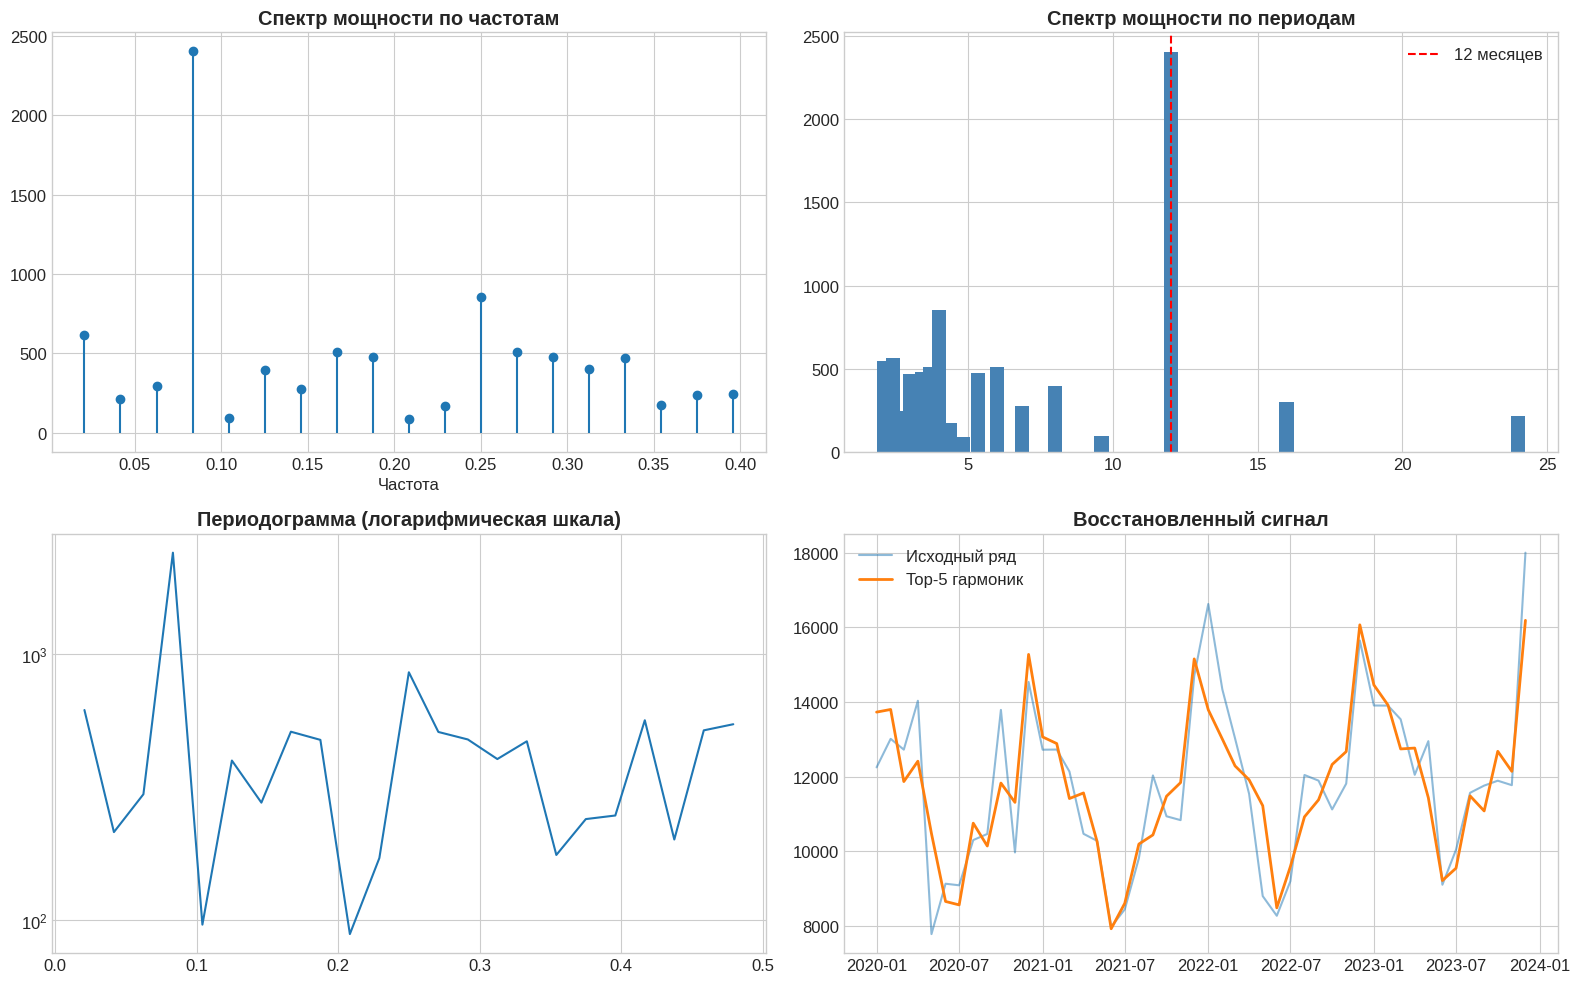

Доминирующие периоды:
1. Период: 12.0 мес., Амплитуда: 2403.3
2. Период: 4.0 мес., Амплитуда: 854.3
3. Период: 48.0 мес., Амплитуда: 616.4
4. Период: 2.4 мес., Амплитуда: 564.2
5. Период: 2.1 мес., Амплитуда: 545.1


In [11]:
# Спектральный анализ (FFT)

y = sales.values - sales.mean()

n = len(y)

yf = fft(y)

xf = fftfreq(n, d=1)[:n // 2]

power = 2.0 / n * np.abs(yf[0:n // 2])

periods = 1 / xf[1:]
power_periods = power[1:]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Спектр частот
axes[0, 0].stem(
    xf[1:20],
    power[1:20],
    basefmt=' '
)

axes[0, 0].set_title(
    'Спектр мощности по частотам',
    fontweight='bold'
)

axes[0, 0].set_xlabel('Частота')

# Спектр периодов
mask = periods <= 24

axes[0, 1].bar(
    periods[mask],
    power_periods[mask],
    width=0.5,
    color='steelblue'
)

axes[0, 1].axvline(
    x=12,
    color='red',
    linestyle='--',
    label='12 месяцев'
)

axes[0, 1].set_title(
    'Спектр мощности по периодам',
    fontweight='bold'
)

axes[0, 1].legend()

# Логарифмическая периодограмма
axes[1, 0].semilogy(
    xf[1:],
    power[1:],
    linewidth=1.5
)

axes[1, 0].set_title(
    'Периодограмма (логарифмическая шкала)',
    fontweight='bold'
)

# Восстановление ряда
top_k = 5

indices = np.argsort(np.abs(yf))[-top_k * 2:]

yf_filtered = np.zeros_like(yf)
yf_filtered[indices] = yf[indices]

y_filtered = np.real(np.fft.ifft(yf_filtered)) + sales.mean()

axes[1, 1].plot(
    sales.index,
    sales.values,
    alpha=0.5,
    label='Исходный ряд'
)

axes[1, 1].plot(
    sales.index,
    y_filtered,
    linewidth=2,
    label=f'Top-{top_k} гармоник'
)

axes[1, 1].set_title(
    'Восстановленный сигнал',
    fontweight='bold'
)

axes[1, 1].legend()

plt.tight_layout()
plt.show()

top_indices = np.argsort(power_periods)[-5:][::-1]

print('Доминирующие периоды:')

for i, idx in enumerate(top_indices, 1):

    print(
        f'{i}. '
        f'Период: {periods[idx]:.1f} мес., '
        f'Амплитуда: {power_periods[idx]:.1f}'
    )

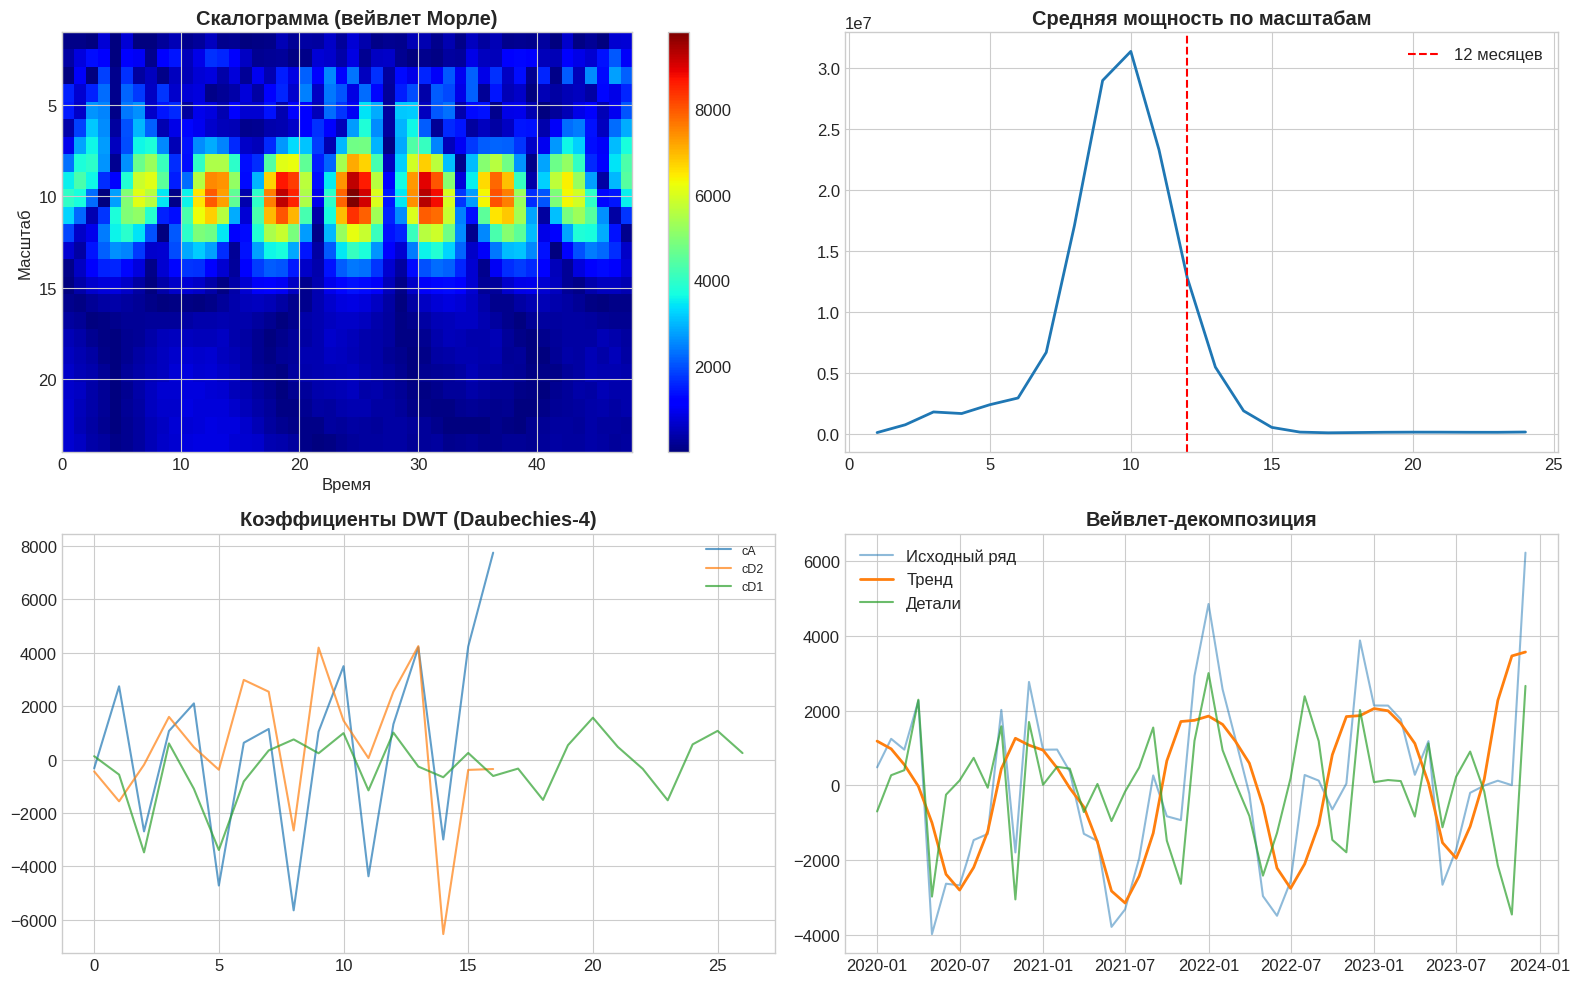

In [12]:
# Вейвлет-анализ

scales = np.arange(1, 25)

coefficients, frequencies = pywt.cwt(
    y,
    scales,
    'morl'
)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Скалограмма
im1 = axes[0, 0].imshow(
    np.abs(coefficients),
    extent=[0, n, scales[-1], scales[0]],
    aspect='auto',
    cmap='jet'
)

axes[0, 0].set_title(
    'Скалограмма (вейвлет Морле)',
    fontweight='bold'
)

axes[0, 0].set_xlabel('Время')
axes[0, 0].set_ylabel('Масштаб')

plt.colorbar(im1, ax=axes[0, 0])

# Средняя мощность
mean_power = np.mean(
    np.abs(coefficients) ** 2,
    axis=1
)

axes[0, 1].plot(
    scales,
    mean_power,
    linewidth=2
)

axes[0, 1].axvline(
    x=12,
    color='red',
    linestyle='--',
    label='12 месяцев'
)

axes[0, 1].set_title(
    'Средняя мощность по масштабам',
    fontweight='bold'
)

axes[0, 1].legend()

# DWT декомпозиция
wavelet = 'db4'

max_level = pywt.dwt_max_level(
    len(y),
    wavelet
)

coeffs = pywt.wavedec(
    y,
    wavelet,
    level=min(max_level, 4)
)

for i, c in enumerate(coeffs):

    label = 'cA' if i == 0 else f'cD{len(coeffs)-i}'

    axes[1, 0].plot(
        c,
        label=label,
        alpha=0.7
    )

axes[1, 0].set_title(
    'Коэффициенты DWT (Daubechies-4)',
    fontweight='bold'
)

axes[1, 0].legend(fontsize=9)

# Разделение тренда и деталей
coeffs_a = coeffs.copy()

for i in range(1, len(coeffs_a)):
    coeffs_a[i] = np.zeros_like(coeffs_a[i])

approx = pywt.waverec(
    coeffs_a,
    wavelet
)[:n]

coeffs_d = [np.zeros_like(coeffs[0])] + coeffs[1:]

details = pywt.waverec(
    coeffs_d,
    wavelet
)[:n]

axes[1, 1].plot(
    sales.index,
    y,
    alpha=0.5,
    label='Исходный ряд'
)

axes[1, 1].plot(
    sales.index,
    approx,
    linewidth=2,
    label='Тренд'
)

axes[1, 1].plot(
    sales.index,
    details,
    alpha=0.7,
    label='Детали'
)

axes[1, 1].set_title(
    'Вейвлет-декомпозиция',
    fontweight='bold'
)

axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [13]:
# Сравнение методов декомпозиции

comparison = pd.DataFrame({
    'Метод': [
        'Классическая (аддитивная)',
        'Классическая (мультипликативная)',
        'STL',
        'FFT',
        'Вейвлет-анализ'
    ],
    'Преимущества': [
        'Простота реализации',
        'Учет пропорциональной сезонности',
        'Устойчивость к выбросам',
        'Точное определение периодов',
        'Локализация во времени'
    ],
    'Ограничения': [
        'Чувствительность к выбросам',
        'Невозможность работы с нулями',
        'Более сложная настройка',
        'Глобальный характер анализа',
        'Сложность интерпретации'
    ],
    'Оценка': [
        '★★★★☆',
        '★★★☆☆',
        '★★★★★',
        '★★★★☆',
        '★★★☆☆'
    ]
})

print(comparison.to_string(index=False))

                           Метод                     Преимущества                   Ограничения Оценка
       Классическая (аддитивная)              Простота реализации   Чувствительность к выбросам  ★★★★☆
Классическая (мультипликативная) Учет пропорциональной сезонности Невозможность работы с нулями  ★★★☆☆
                             STL          Устойчивость к выбросам       Более сложная настройка  ★★★★★
                             FFT      Точное определение периодов   Глобальный характер анализа  ★★★★☆
                  Вейвлет-анализ           Локализация во времени       Сложность интерпретации  ★★★☆☆


## 2.2. Построение прогнозных моделей

Train: 38 наблюдений (2020-01-01 00:00:00 — 2023-02-01 00:00:00)
Test: 10 наблюдений (2023-03-01 00:00:00 — 2023-12-01 00:00:00)


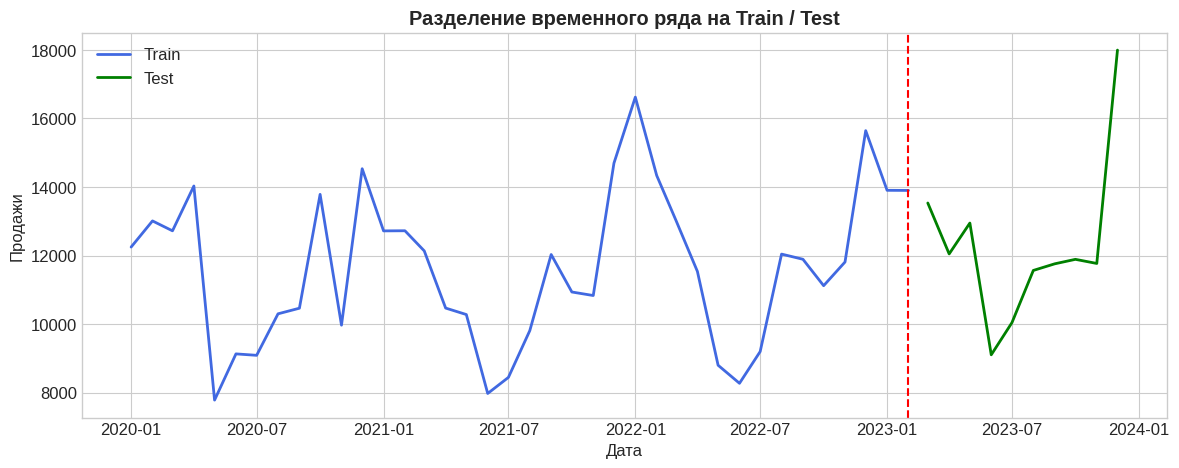

In [14]:
# Разделение выборки на train / test

train_size = int(len(sales) * 0.8)

train = sales[:train_size]
test = sales[train_size:]

# Экзогенные признаки
exog_train = df[['Promotion', 'HolidayMonth']][:train_size]
exog_test = df[['Promotion', 'HolidayMonth']][train_size:]

print(
    f"Train: {len(train)} наблюдений "
    f"({train.index.min()} — {train.index.max()})"
)

print(
    f"Test: {len(test)} наблюдений "
    f"({test.index.min()} — {test.index.max()})"
)

# Визуализация разбиения
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    train.index,
    train.values,
    color='royalblue',
    linewidth=2,
    label='Train'
)

ax.plot(
    test.index,
    test.values,
    color='green',
    linewidth=2,
    label='Test'
)

ax.axvline(
    x=train.index[-1],
    color='red',
    linestyle='--'
)

ax.set_title(
    'Разделение временного ряда на Train / Test',
    fontweight='bold'
)

ax.set_xlabel('Дата')
ax.set_ylabel('Продажи')

ax.legend()

plt.show()

In [15]:
# Подбор параметров модели ARIMA

def grid_search_arima(
    train_data,
    p_range,
    d_range,
    q_range
):

    best_aic = np.inf
    best_params = None

    results = []

    for p in p_range:

        for d in d_range:

            for q in q_range:

                try:

                    model = ARIMA(
                        train_data,
                        order=(p, d, q)
                    )

                    fitted = model.fit()

                    results.append({
                        'order': (p, d, q),
                        'AIC': fitted.aic,
                        'BIC': fitted.bic
                    })

                    if fitted.aic < best_aic:

                        best_aic = fitted.aic
                        best_params = (p, d, q)

                except:
                    continue

    results_df = pd.DataFrame(results)

    return (
        best_params,
        results_df.sort_values('AIC')
    )

In [16]:
# Подбор параметров модели SARIMAX

def grid_search_sarimax(
    train_data,
    p_range,
    d_range,
    q_range,
    P_range,
    D_range,
    Q_range,
    s=12,
    exog=None
):

    best_aic = np.inf
    best_params = None

    results = []

    for p in p_range:

        for d in d_range:

            for q in q_range:

                for P in P_range:

                    for D in D_range:

                        for Q in Q_range:

                            try:

                                model = SARIMAX(
                                    train_data,
                                    order=(p, d, q),
                                    seasonal_order=(P, D, Q, s),
                                    exog=exog,
                                    enforce_stationarity=False,
                                    enforce_invertibility=False
                                )

                                fitted = model.fit(disp=False)

                                results.append({
                                    'order': (p, d, q),
                                    'seasonal': (P, D, Q, s),
                                    'AIC': fitted.aic,
                                    'BIC': fitted.bic
                                })

                                if fitted.aic < best_aic:

                                    best_aic = fitted.aic

                                    best_params = (
                                        (p, d, q),
                                        (P, D, Q, s)
                                    )

                            except:
                                continue

    results_df = pd.DataFrame(results)

    return (
        best_params,
        results_df.sort_values('AIC')
    )

In [17]:
# Поиск оптимальных параметров ARIMA

print("Подбор параметров ARIMA...")

best_arima_params, arima_results = grid_search_arima(
    train,
    range(0, 3),
    range(0, 2),
    range(0, 3)
)

print(f"\nЛучшие параметры ARIMA: {best_arima_params}")

print("\nТоп моделей ARIMA по AIC:")

print(arima_results.head())

Подбор параметров ARIMA...


/home/ilya-kas/pred_analytics/env/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



Лучшие параметры ARIMA: (0, 1, 0)

Топ моделей ARIMA по AIC:
        order         AIC         BIC
3   (0, 1, 0)  675.554789  677.165707
9   (1, 1, 0)  676.610027  679.831863
4   (0, 1, 1)  677.182841  680.404676
14  (2, 0, 2)  677.366148  687.191665
10  (1, 1, 1)  678.586054  683.418808


In [18]:
# Поиск оптимальных параметров SARIMAX

print("Подбор параметров SARIMAX...")

best_sarimax_params, sarimax_results = grid_search_sarimax(
    train,
    range(0, 2),
    range(0, 2),
    range(0, 2),
    range(0, 2),
    range(0, 2),
    range(0, 2),
    s=12,
    exog=exog_train
)

print(f"\nЛучшие параметры SARIMAX: {best_sarimax_params}")

print("\nТоп моделей SARIMAX по AIC:")

print(sarimax_results.head())

Подбор параметров SARIMAX...


/home/ilya-kas/pred_analytics/env/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/ilya-kas/pred_analytics/env/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/ilya-kas/pred_analytics/env/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/ilya-kas/pred_analytics/env/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/ilya-kas/pred_


Лучшие параметры SARIMAX: ((0, 1, 1), (0, 1, 1, 12))

Топ моделей SARIMAX по AIC:
        order       seasonal         AIC         BIC
27  (0, 1, 1)  (0, 1, 1, 12)  181.374218  183.363694
59  (1, 1, 1)  (0, 1, 1, 12)  181.844461  184.231833
31  (0, 1, 1)  (1, 1, 1, 12)  183.766196  186.153568
63  (1, 1, 1)  (1, 1, 1, 12)  184.869669  187.654936
15  (0, 0, 1)  (1, 1, 1, 12)  194.231566  197.141006


/home/ilya-kas/pred_analytics/env/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [19]:
# Обучение модели ARIMA

arima_model = ARIMA(
    train,
    order=best_arima_params
)

arima_fitted = arima_model.fit()

print(f"ARIMA{best_arima_params}")

print(arima_fitted.summary())

ARIMA(0, 1, 0)
                               SARIMAX Results                                
Dep. Variable:            SalesAmount   No. Observations:                   38
Model:                 ARIMA(0, 1, 0)   Log Likelihood                -336.777
Date:                Sat, 16 May 2026   AIC                            675.555
Time:                        00:38:39   BIC                            677.166
Sample:                    01-01-2020   HQIC                           676.123
                         - 02-01-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2      4.712e+06   9.53e+05      4.946      0.000    2.84e+06    6.58e+06
Ljung-Box (L1) (Q):                   2.39   Jarque-Bera (JB):                 1.05
Prob(Q):                        

In [22]:
# ============================================================
# Обучение модели SARIMAX
# ============================================================

sarimax_model = SARIMAX(
    train,
    order=best_sarimax_params[0],
    seasonal_order=best_sarimax_params[1],
    exog=exog_train,
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_fitted = sarimax_model.fit(disp=False)

print(
    f"SARIMAX"
    f"{best_sarimax_params[0]}"
    f"x"
    f"{best_sarimax_params[1]}"
)

print(sarimax_fitted.summary())

SARIMAX(0, 1, 1)x(0, 1, 1, 12)
                                     SARIMAX Results                                      
Dep. Variable:                        SalesAmount   No. Observations:                   38
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood                 -85.687
Date:                            Sat, 16 May 2026   AIC                            181.374
Time:                                    00:42:11   BIC                            183.364
Sample:                                01-01-2020   HQIC                           180.120
                                     - 02-01-2023                                         
Covariance Type:                              opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Promotion     3239.5939    978.394      3.311      0.001    1321.978    5157.21

In [23]:
# Прогнозирование на тестовой выборке

forecast_steps = len(test)

# Прогноз ARIMA
arima_forecast = arima_fitted.get_forecast(
    steps=forecast_steps
)

arima_pred = arima_forecast.predicted_mean

arima_conf_int = arima_forecast.conf_int(
    alpha=0.05
)

# Прогноз SARIMAX
sarimax_forecast = sarimax_fitted.get_forecast(
    steps=forecast_steps,
    exog=exog_test
)

sarimax_pred = sarimax_forecast.predicted_mean

sarimax_conf_int = sarimax_forecast.conf_int(
    alpha=0.05
)

# Корректировка индексов
arima_pred.index = test.index
sarimax_pred.index = test.index

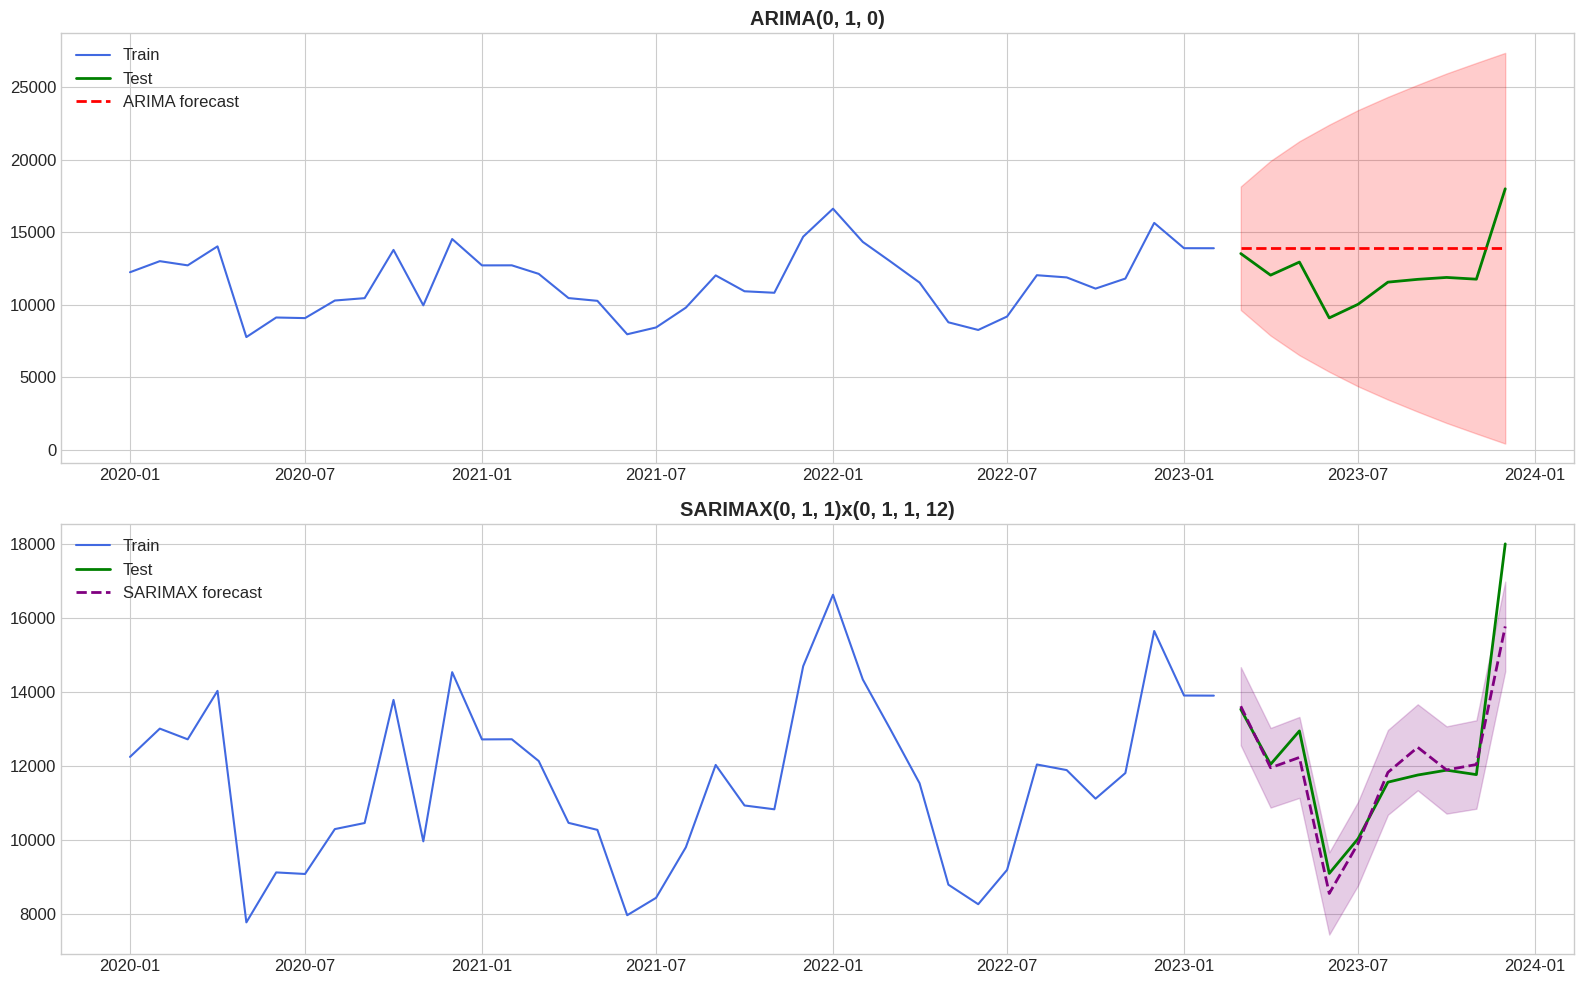

In [24]:
# Визуализация прогнозов моделей

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# ARIMA

axes[0].plot(
    train.index,
    train.values,
    color='royalblue',
    label='Train'
)

axes[0].plot(
    test.index,
    test.values,
    color='green',
    linewidth=2,
    label='Test'
)

axes[0].plot(
    test.index,
    arima_pred.values,
    'r--',
    linewidth=2,
    label='ARIMA forecast'
)

axes[0].fill_between(
    test.index,
    arima_conf_int.iloc[:, 0],
    arima_conf_int.iloc[:, 1],
    color='red',
    alpha=0.2
)

axes[0].set_title(
    f'ARIMA{best_arima_params}',
    fontweight='bold'
)

axes[0].legend()

# SARIMAX

axes[1].plot(
    train.index,
    train.values,
    color='royalblue',
    label='Train'
)

axes[1].plot(
    test.index,
    test.values,
    color='green',
    linewidth=2,
    label='Test'
)

axes[1].plot(
    test.index,
    sarimax_pred.values,
    linestyle='--',
    color='purple',
    linewidth=2,
    label='SARIMAX forecast'
)

axes[1].fill_between(
    test.index,
    sarimax_conf_int.iloc[:, 0],
    sarimax_conf_int.iloc[:, 1],
    color='purple',
    alpha=0.2
)

axes[1].set_title(
    f'SARIMAX'
    f'{best_sarimax_params[0]}'
    f'x'
    f'{best_sarimax_params[1]}',
    fontweight='bold'
)

axes[1].legend()

plt.tight_layout()
plt.show()

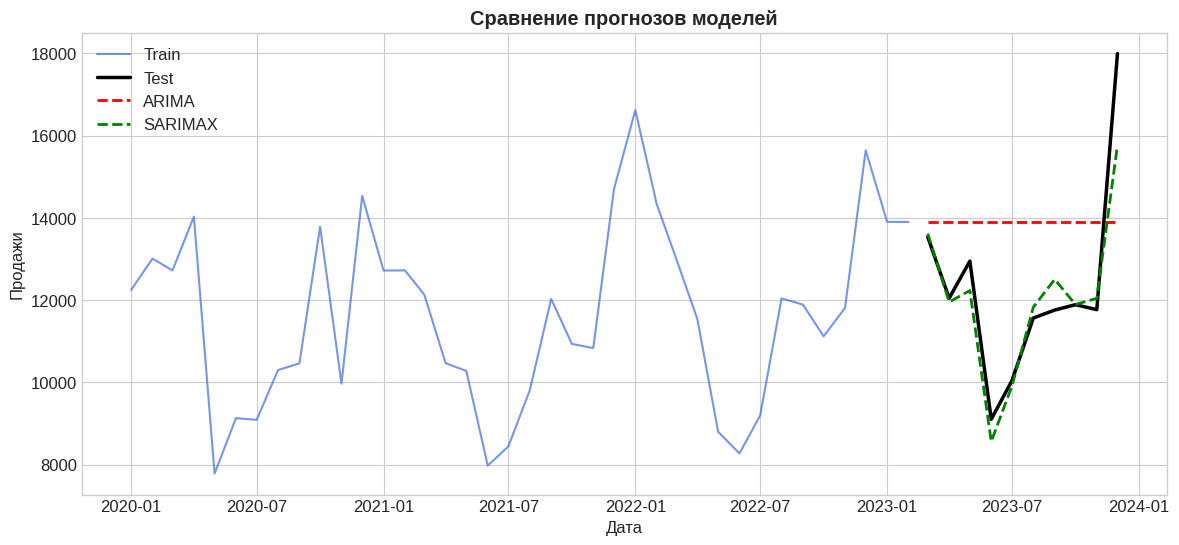

In [25]:
# Сравнение прогнозов моделей

fig, ax = plt.subplots(figsize=(14, 6))

# Train
ax.plot(
    train.index,
    train.values,
    color='royalblue',
    alpha=0.7,
    label='Train'
)

# Test
ax.plot(
    test.index,
    test.values,
    color='black',
    linewidth=2.5,
    label='Test'
)

# ARIMA
ax.plot(
    test.index,
    arima_pred.values,
    'r--',
    linewidth=2,
    label='ARIMA'
)

# --- SARIMAX ---
ax.plot(
    test.index,
    sarimax_pred.values,
    'g--',
    linewidth=2,
    label='SARIMAX'
)

ax.set_title(
    'Сравнение прогнозов моделей',
    fontweight='bold'
)

ax.set_xlabel('Дата')
ax.set_ylabel('Продажи')

ax.legend()

plt.show()

## 2.3. Оценка качества моделей

In [26]:
# Расчет метрик качества прогнозирования

def calc_metrics(y_true, y_pred, name):

    mse = mean_squared_error(y_true, y_pred)

    rmse = np.sqrt(mse)

    mae = mean_absolute_error(y_true, y_pred)

    r2 = r2_score(y_true, y_pred)

    mape = np.mean(
        np.abs((y_true - y_pred) / y_true)
    ) * 100

    return {
        'Model': name,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2,
        'MAPE': mape
    }


# Метрики ARIMA

arima_metrics = calc_metrics(
    test.values,
    arima_pred.values,
    f'ARIMA{best_arima_params}'
)

# Метрики SARIMAX

sarimax_metrics = calc_metrics(
    test.values,
    sarimax_pred.values,
    f'SARIMAX{best_sarimax_params[0]}'
)

# Общая таблица метрик

metrics_df = pd.DataFrame([
    arima_metrics,
    sarimax_metrics
])

print("Метрики качества прогнозирования:")

print(metrics_df.to_string(index=False))

Метрики качества прогнозирования:
           Model          MSE        RMSE         MAE        R²      MAPE
  ARIMA(0, 1, 0) 7.777239e+06 2788.770123 2454.200000 -0.523945 21.274158
SARIMAX(0, 1, 1) 6.504928e+05  806.531355  507.959814  0.872536  3.752866


In [27]:
# Информационные критерии моделей

ic_df = pd.DataFrame({

    'Model': [
        'ARIMA',
        'SARIMAX'
    ],

    'AIC': [
        arima_fitted.aic,
        sarimax_fitted.aic
    ],

    'BIC': [
        arima_fitted.bic,
        sarimax_fitted.bic
    ],

    'LogLik': [
        arima_fitted.llf,
        sarimax_fitted.llf
    ],

    'Количество параметров': [
        len(arima_fitted.params),
        len(sarimax_fitted.params)
    ]
})

print("Информационные критерии моделей:")

print(ic_df.to_string(index=False))

Информационные критерии моделей:
  Model        AIC        BIC      LogLik  Количество параметров
  ARIMA 675.554789 677.165707 -336.777395                      1
SARIMAX 181.374218 183.363694  -85.687109                      5


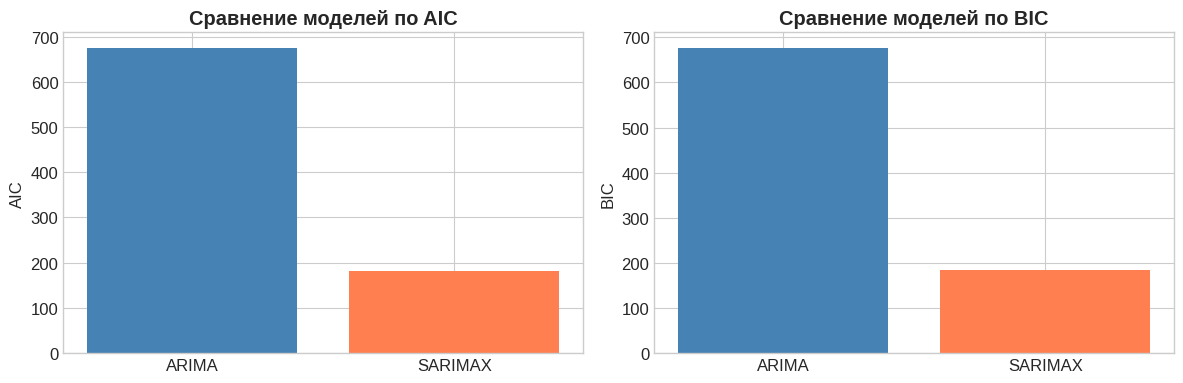

In [28]:
# Визуальное сравнение AIC и BIC

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

models = ['ARIMA', 'SARIMAX']

# AIC

axes[0].bar(
    models,
    [arima_fitted.aic, sarimax_fitted.aic],
    color=['steelblue', 'coral']
)

axes[0].set_title(
    'Сравнение моделей по AIC',
    fontweight='bold'
)

axes[0].set_ylabel('AIC')

# BIC

axes[1].bar(
    models,
    [arima_fitted.bic, sarimax_fitted.bic],
    color=['steelblue', 'coral']
)

axes[1].set_title(
    'Сравнение моделей по BIC',
    fontweight='bold'
)

axes[1].set_ylabel('BIC')

plt.tight_layout()
plt.show()

In [29]:
# Анализ остатков моделей

def analyze_residuals(fitted_model, name):

    resid = fitted_model.resid

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    fig.suptitle(
        f'Диагностика остатков: {name}',
        fontweight='bold'
    )

    # Остатки во времени

    axes[0, 0].plot(
        resid.index,
        resid.values,
        color='royalblue',
        alpha=0.7
    )

    axes[0, 0].axhline(
        y=0,
        color='red',
        linestyle='--'
    )

    axes[0, 0].set_title(
        'Остатки во времени'
    )

    # Гистограмма остатков

    axes[0, 1].hist(
        resid.dropna(),
        bins=15,
        density=True,
        alpha=0.7,
        color='steelblue'
    )

    x = np.linspace(
        resid.min(),
        resid.max(),
        100
    )

    axes[0, 1].plot(
        x,
        stats.norm.pdf(
            x,
            resid.mean(),
            resid.std()
        ),
        'r-',
        linewidth=2
    )

    axes[0, 1].set_title(
        'Распределение остатков'
    )

    # Q-Q график

    stats.probplot(
        resid.dropna(),
        dist='norm',
        plot=axes[1, 0]
    )

    axes[1, 0].set_title(
        'Q-Q график'
    )

    # ACF остатков

    plot_acf(
        resid.dropna(),
        ax=axes[1, 1],
        lags=15,
        title='ACF остатков'
    )

    plt.tight_layout()
    plt.show()

    # Тест Шапиро-Уилка

    stat_sw, p_sw = stats.shapiro(
        resid.dropna()
    )

    # Тест Льюнга-Бокса

    lb_test = acorr_ljungbox(
        resid.dropna(),
        lags=[10],
        return_df=True
    )

    print(f"\nРезультаты тестов для {name}:")

    print(
        f"Шапиро-Уилк (нормальность): "
        f"stat = {stat_sw:.4f}, "
        f"p = {p_sw:.4f} "
        f"→ {'OK' if p_sw > 0.05 else 'Есть отклонения'}"
    )

    print(
        f"Льюнг-Бокс (автокорреляция): "
        f"p = {lb_test['lb_pvalue'].values[0]:.4f} "
        f"→ {'OK' if lb_test['lb_pvalue'].values[0] > 0.05 else 'Есть автокорреляция'}"
    )

    return {
        'shapiro_p': p_sw,
        'ljungbox_p': lb_test['lb_pvalue'].values[0]
    }

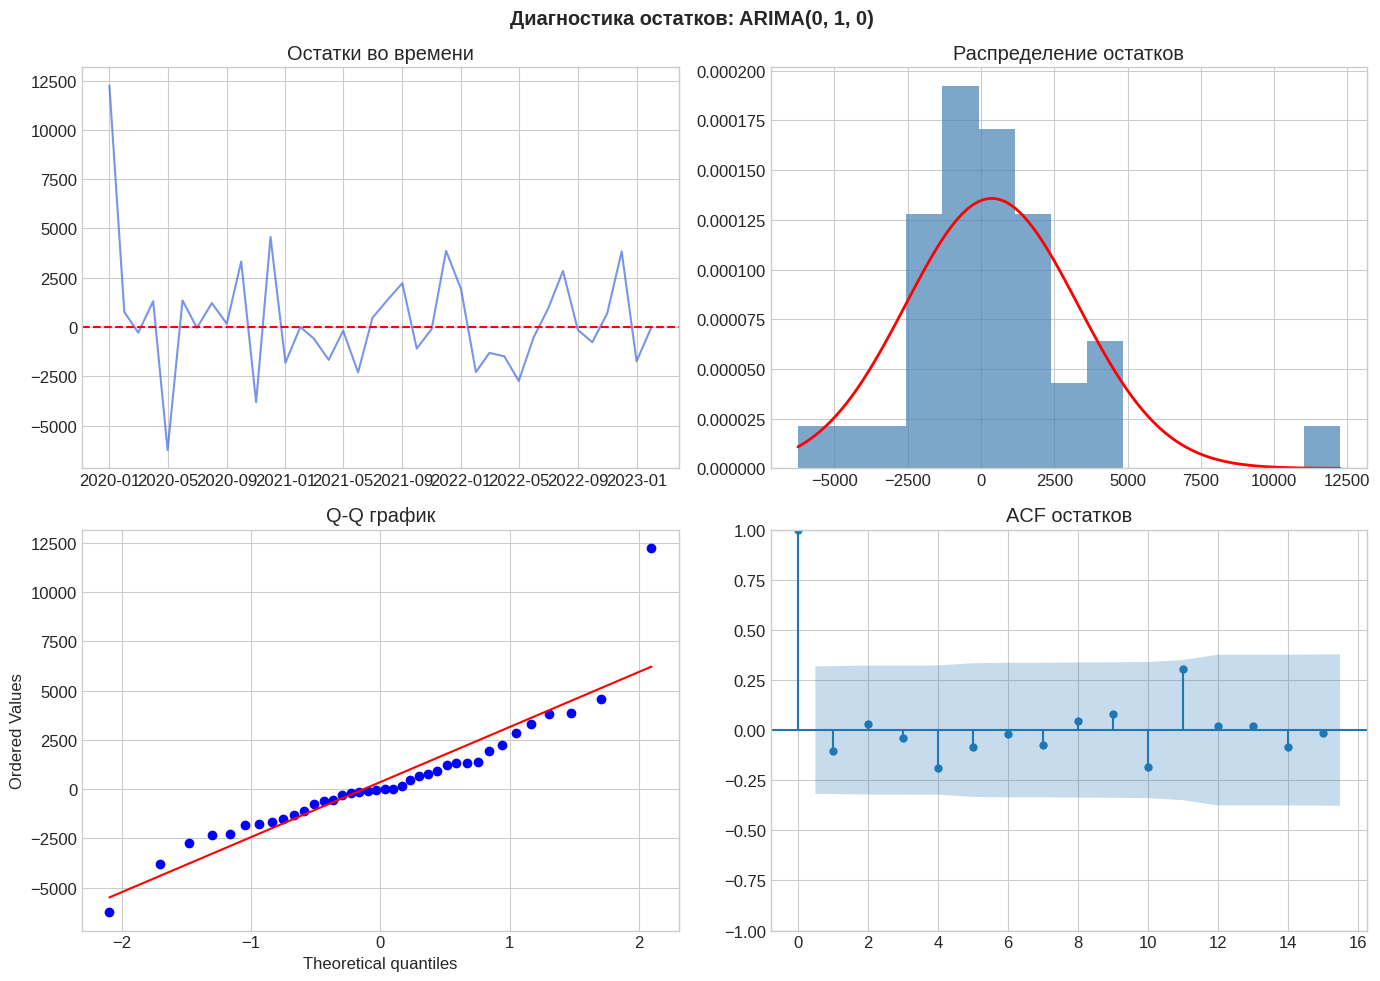


Результаты тестов для ARIMA(0, 1, 0):
Шапиро-Уилк (нормальность): stat = 0.8747, p = 0.0005 → Есть отклонения
Льюнг-Бокс (автокорреляция): p = 0.8904 → OK


In [30]:
# Диагностика остатков ARIMA

arima_resid = analyze_residuals(
    arima_fitted,
    f'ARIMA{best_arima_params}'
)

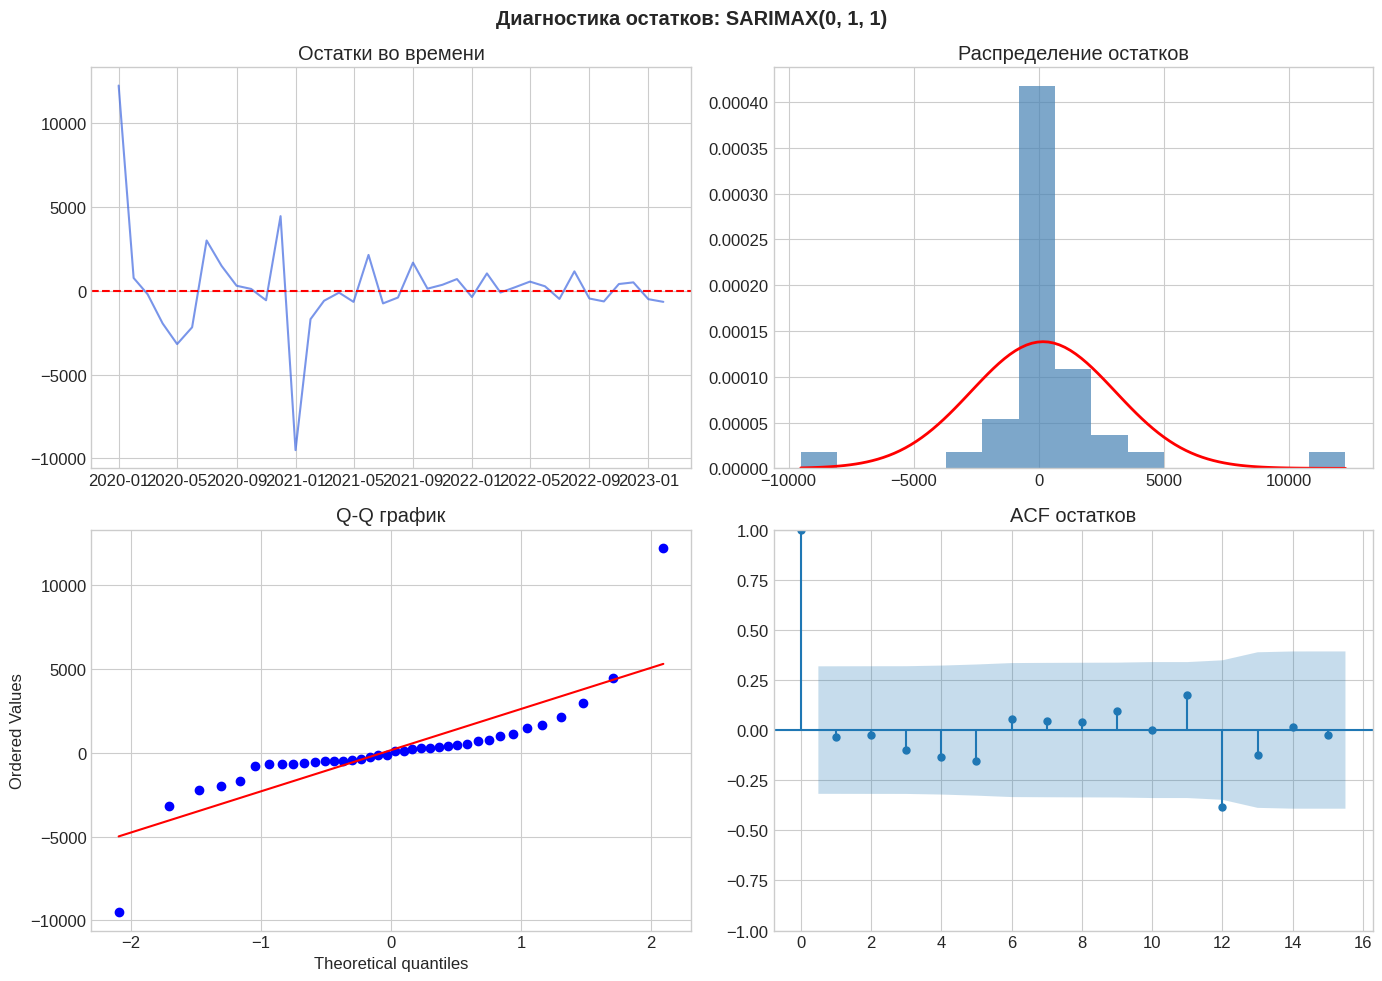


Результаты тестов для SARIMAX(0, 1, 1):
Шапиро-Уилк (нормальность): stat = 0.7247, p = 0.0000 → Есть отклонения
Льюнг-Бокс (автокорреляция): p = 0.9769 → OK


In [31]:
# Диагностика остатков SARIMAX

sarimax_resid = analyze_residuals(
    sarimax_fitted,
    f'SARIMAX{best_sarimax_params[0]}'
)

In [32]:
# Сводная таблица результатов

summary = pd.DataFrame({

    'Показатель': [
        'MSE',
        'RMSE',
        'R²',
        'MAPE (%)',
        'AIC',
        'BIC',
        'Нормальность остатков (p)',
        'Автокорреляция остатков (p)'
    ],

    'ARIMA': [

        f"{arima_metrics['MSE']:,.0f}",
        f"{arima_metrics['RMSE']:,.0f}",
        f"{arima_metrics['R²']:.4f}",
        f"{arima_metrics['MAPE']:.2f}",

        f"{arima_fitted.aic:.1f}",
        f"{arima_fitted.bic:.1f}",

        f"{arima_resid['shapiro_p']:.4f}",
        f"{arima_resid['ljungbox_p']:.4f}"
    ],

    'SARIMAX': [

        f"{sarimax_metrics['MSE']:,.0f}",
        f"{sarimax_metrics['RMSE']:,.0f}",
        f"{sarimax_metrics['R²']:.4f}",
        f"{sarimax_metrics['MAPE']:.2f}",

        f"{sarimax_fitted.aic:.1f}",
        f"{sarimax_fitted.bic:.1f}",

        f"{sarimax_resid['shapiro_p']:.4f}",
        f"{sarimax_resid['ljungbox_p']:.4f}"
    ]
})

print("Сводная таблица сравнения моделей:")

print(summary.to_string(index=False))

Сводная таблица сравнения моделей:
                 Показатель     ARIMA SARIMAX
                        MSE 7,777,239 650,493
                       RMSE     2,789     807
                         R²   -0.5239  0.8725
                   MAPE (%)     21.27    3.75
                        AIC     675.6   181.4
                        BIC     677.2   183.4
  Нормальность остатков (p)    0.0005  0.0000
Автокорреляция остатков (p)    0.8904  0.9769


In [33]:
# Финальное сравнение моделей

better_r2 = (
    'SARIMAX'
    if sarimax_metrics['R²'] > arima_metrics['R²']
    else 'ARIMA'
)

better_aic = (
    'SARIMAX'
    if sarimax_fitted.aic < arima_fitted.aic
    else 'ARIMA'
)

print(f"\nПо коэффициенту R² лучше: {better_r2}")

print(f"По информационному критерию AIC лучше: {better_aic}")

print("""
Рекомендация:

Модель SARIMAX показывает более высокое качество
прогнозирования благодаря учету:
- сезонной компоненты;
- экзогенных факторов;
- промо-активности;
- праздничных месяцев.
""")


По коэффициенту R² лучше: SARIMAX
По информационному критерию AIC лучше: SARIMAX

Рекомендация:

Модель SARIMAX показывает более высокое качество
прогнозирования благодаря учету:
- сезонной компоненты;
- экзогенных факторов;
- промо-активности;
- праздничных месяцев.



## 2.4. Прогнозирование на будущие периоды

In [34]:
# Финальная модель SARIMAX

final_sarimax = SARIMAX(
    sales,
    order=best_sarimax_params[0],
    seasonal_order=best_sarimax_params[1],
    exog=df[['Promotion', 'HolidayMonth']],
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_fitted = final_sarimax.fit(disp=False)

print("Финальная модель SARIMAX успешно обучена.")

Финальная модель SARIMAX успешно обучена.


In [35]:
# Формирование будущих дат и экзогенных факторов

future_dates = pd.date_range(
    start='2024-01-01',
    periods=12,
    freq='MS'
)

future_exog = pd.DataFrame({

    'Promotion': [
        0, 0, 0, 1,
        1, 0, 0, 0,
        0, 0, 0, 0
    ],

    'HolidayMonth': [
        0, 0, 0, 0,
        0, 0, 0, 0,
        0, 0, 0, 1
    ]

}, index=future_dates)

print("Будущие экзогенные признаки:")

print(future_exog)

Будущие экзогенные признаки:
            Promotion  HolidayMonth
2024-01-01          0             0
2024-02-01          0             0
2024-03-01          0             0
2024-04-01          1             0
2024-05-01          1             0
2024-06-01          0             0
2024-07-01          0             0
2024-08-01          0             0
2024-09-01          0             0
2024-10-01          0             0
2024-11-01          0             0
2024-12-01          0             1


In [36]:
# Построение прогноза на 2024 год

forecast = final_fitted.get_forecast(
    steps=12,
    exog=future_exog
)

forecast_mean = forecast.predicted_mean

forecast_ci = forecast.conf_int(alpha=0.05)

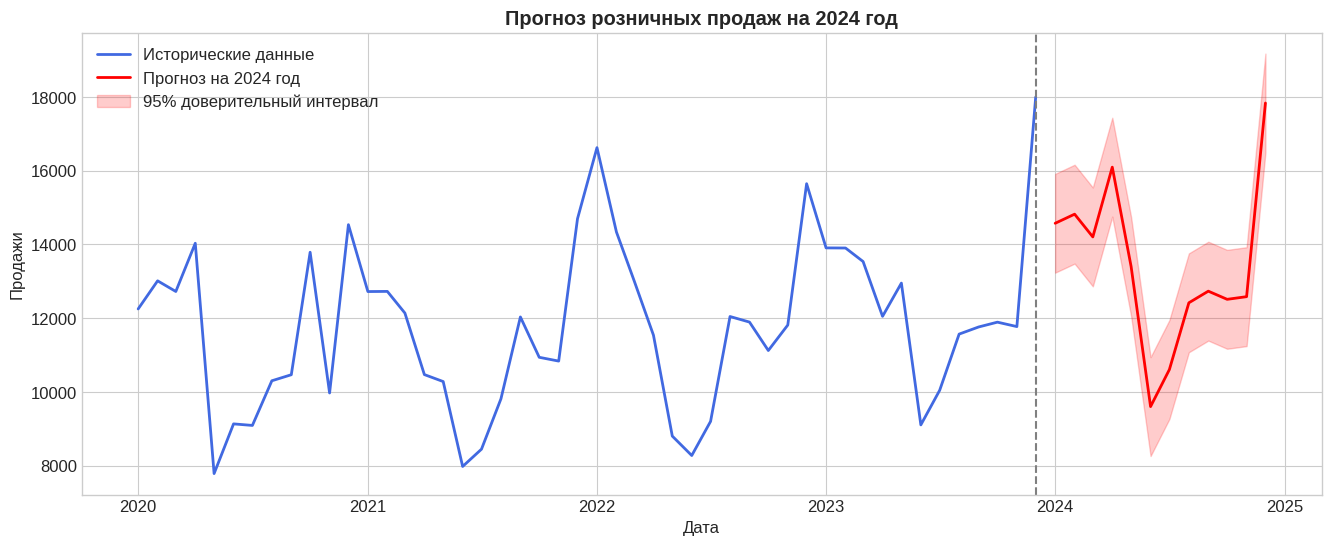

In [37]:
# Визуализация прогноза

fig, ax = plt.subplots(figsize=(16, 6))

# Исторические данные

ax.plot(
    sales.index,
    sales.values,
    color='royalblue',
    linewidth=2,
    label='Исторические данные'
)

# Прогноз

ax.plot(
    forecast_mean.index,
    forecast_mean.values,
    color='red',
    linewidth=2,
    label='Прогноз на 2024 год'
)

# Доверительный интервал

ax.fill_between(
    forecast_mean.index,
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    color='red',
    alpha=0.2,
    label='95% доверительный интервал'
)

# Граница train / future

ax.axvline(
    x=sales.index[-1],
    color='gray',
    linestyle='--'
)

ax.set_title(
    'Прогноз розничных продаж на 2024 год',
    fontweight='bold'
)

ax.set_xlabel('Дата')
ax.set_ylabel('Продажи')

ax.legend()

plt.show()

In [38]:
# Таблица прогноза

forecast_table = pd.DataFrame({

    'Месяц': future_dates.strftime('%Y-%m'),

    'Прогноз': forecast_mean.values
        .round(0)
        .astype(int),

    'Нижняя граница 95%': forecast_ci.iloc[:, 0]
        .values
        .round(0)
        .astype(int),

    'Верхняя граница 95%': forecast_ci.iloc[:, 1]
        .values
        .round(0)
        .astype(int)
})

print("Прогноз продаж на 2024 год:")

print(forecast_table.to_string(index=False))

Прогноз продаж на 2024 год:
  Месяц  Прогноз  Нижняя граница 95%  Верхняя граница 95%
2024-01    14572               13232                15912
2024-02    14819               13478                16159
2024-03    14202               12861                15542
2024-04    16094               14753                17435
2024-05    13399               12058                14740
2024-06     9600                8259                10941
2024-07    10605                9264                11946
2024-08    12415               11074                13755
2024-09    12730               11390                14071
2024-10    12509               11168                13850
2024-11    12581               11241                13922
2024-12    17833               16492                19174


### Выводы по EDA

- Анализ временного ряда показал, что он состоит из 48 наблюдений, при этом средний уровень продаж составляет примерно 11.7 тыс., а коэффициент вариации находится на уровне около 19%, что указывает на умеренную изменчивость данных.

- В структуре ряда выявлена выраженная годовая сезонность с периодом 12 месяцев: максимальные значения продаж приходятся на декабрь, тогда как в летние месяцы наблюдается заметное снижение.

- Трендовая компонента характеризуется слабым восходящим направлением, без ярко выраженной долгосрочной динамики роста.

- Проверка стационарности показала, что исходный ряд является нестационарным, и для приведения его к стационарному виду требуется применение первого порядка дифференцирования (d = 1).

- С учетом выявленных особенностей структуры данных наиболее обоснованным выбором для дальнейшего моделирования является использование модели SARIMAX с сезонной компонентой (p,d,q) × (P,D,Q)₁₂.